In [1]:
from graphiti_core import Graphiti
from graphiti_core.driver.neo4j_driver import Neo4jDriver
from graphiti_core.llm_client import LLMConfig
from graphiti_core.llm_client.gemini_client import GeminiClient
from graphiti_core.embedder.gemini import GeminiEmbedder, GeminiEmbedderConfig
from graphiti_core.cross_encoder.gemini_reranker_client import GeminiRerankerClient
from graphiti_core.utils.maintenance.graph_data_operations import clear_data

import os
from dotenv import load_dotenv
load_dotenv("/Users/mac/Documents/PHUNGPX/knowledge_graph_searching/.env")

GEMINI_BASE_URL = "https://generativelanguage.googleapis.com/v1beta/openai/"
GEMINI_API_KEY = os.environ["LLM_API_KEY"]

class GraphitiClient:
    def __init__(self):
        self.llm_client = GeminiClient(
            config=LLMConfig(
                base_url=GEMINI_BASE_URL,
                api_key=GEMINI_API_KEY,
                model=os.environ["LLM_MODEL"],
            )
        )

        self.cross_encoder = GeminiRerankerClient(
            config=LLMConfig(
                base_url=GEMINI_BASE_URL,
                api_key=GEMINI_API_KEY,
                model=os.environ["RERANKER_MODEL"],
            )
        )

        self.embedder = GeminiEmbedder(
            config=GeminiEmbedderConfig(
                base_url=GEMINI_BASE_URL,
                api_key=GEMINI_API_KEY,
                embedding_model=os.environ["EMBEDDING_MODEL"],
                embedding_dim=os.environ["EMBEDDING_DIMENSIONS"],
            )
        )

        self.driver = Neo4jDriver(
            uri=os.environ["GRAPH_DB_URL"],
            user=os.environ["GRAPH_DB_USERNAME"],
            password=os.environ["GRAPH_DB_PASSWORD"],
        )

    async def create_client(
        self,
        clear_existing_graphdb_data: bool = False,
        max_coroutines: int = 1,
    ):
        graphiti = Graphiti(
            graph_driver=self.driver,
            llm_client=self.llm_client,
            embedder=self.embedder,
            cross_encoder=self.cross_encoder,
            max_coroutines=max_coroutines,
        )

        # Initialize the graph database with graphiti's indices
        await graphiti.build_indices_and_constraints()

        if clear_existing_graphdb_data:
            print("[GraphitiClient] Clearing existing graph data...")
            await clear_data(graphiti.driver)
            print("[GraphitiClient] Graph data cleared successfully.")

        return graphiti


In [ ]:
from graphiti_core.search.search_config_recipes import COMBINED_HYBRID_SEARCH_CROSS_ENCODER
from graphiti_core.search.search_config import SearchResults

def get_node_and_edge_contents(result: SearchResults) -> tuple[list[str], list[str]]:
    edge_contents = []
    node_contents = []

    if hasattr(result, "nodes") and result.nodes:
        node_contents = [edge.summary for edge in result.nodes]

    if hasattr(result, "edges") and result.edges:
        edge_contents = [edge.fact for edge in result.edges]

    return node_contents, edge_contents

async def search_durian_pest_and_disease_knowledge(question: str, limit: int = 3) -> tuple[list[str], list[str]]:
    """Search knowledge graph for information about pest and disease on durian"""
    graphiti = await GraphitiClient().create_client(
        clear_existing_graphdb_data=False,
        max_coroutines=1,
    )

    search_type = COMBINED_HYBRID_SEARCH_CROSS_ENCODER.model_copy(deep=True)
    search_type.limit = limit

    results = await graphiti.search_(query=question, config=search_type)

    return get_node_and_edge_contents(results)


In [4]:
from langgraph.prebuilt import ToolNode
from langchain_google_genai import ChatGoogleGenerativeAI

os.environ["GOOGLE_API_KEY"] = os.getenv("LLM_API_KEY")

tools = [search_durian_pest_and_disease_knowledge]
tool_node = ToolNode(tools)

llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash", temperature=0)
llm_with_tools = llm.bind_tools(tools)

In [5]:
# Test the tool node
response = await tool_node.ainvoke({'messages': [await llm_with_tools.ainvoke('How can I control bright leaf?')]})

In [18]:
from typing import Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI

# Data model
class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource."""
    datasource: Literal["knowledge_graph_retrieval", "web_search"] = Field(
        description="Given a user question choose to route it to web search or knowledge graph retrieval."
    )


# LLM with function call
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash", temperature=0)
structured_llm_router = llm.with_structured_output(RouteQuery)

# Prompt
system = """You are an expert at routing a user question to a knowledge graph retrieval or web search. The knowledge graph contains documents related to durian pest and disease. Use the knowledge graph retrieval for questions on these topics. Otherwise, use web search."""
route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

question_router = route_prompt | structured_llm_router

In [19]:
question = "Who will the Bears draft first in the NFL draft?"
response = question_router.invoke({"question": question})
print("Quesion:", question)
print("Datasource:", response.datasource)

Quesion: Who will the Bears draft first in the NFL draft?
Datasource: web_search


In [20]:
question = "How can I control this symptom on my durian?"
response = question_router.invoke({"question": question})
print("Quesion:", question)
print("Datasource:", response.datasource)

Quesion: How can I control this symptom on my durian?
Datasource: knowledge_graph_retrieval


In [21]:
# Data model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader

In [32]:
question = 'My young durian leaves are curling and look scorched at the edges—could that be leafhopper damage and what should I do first?'
node_contents, edge_contents = await search_durian_pest_and_disease_knowledge(question, limit=3)

In [33]:
node_contents

['The Durian leafhopper (Amrasca durianae) causes damage by sucking sap from young leaves and releasing toxins. This leads to a scalded appearance, followed by drying, curling, and eventual shedding of the leaves, leaving petioles bare. Control methods include using sticky traps for adults, spraying with biological agents like Beauveria, Metarhizium, or Neem extract, and applying chemical insecticides such as Carbosulfan, Imidacloprid, Fipronil, or Abamectin.',
 'The Durian leafhopper (Amrasca durianae) is an insect pest occasionally found in durian cultivation in Thailand. While not as significant as major pests, it is listed among the occasional insect and mite pests that affect durian trees. Information regarding its specific damage characteristics, life cycle, or control methods is not detailed within the provided texts, beyond its classification as an occasional pest.',
 'Amrasca durianae, or the durian leafhopper, is an insect pest that can damage durian plants in Thailand. While

In [34]:
edge_contents

['Durian psyllids only damage young, not fully developed durian leaves.',
 'In durian, several species of thrips are found causing damage at various developmental stages, but the most common and significant is the chili thrips, which infests during the young fruit and young leaf stages.',
 'In plots where Leaf Blight outbreaks are common, high-nitrogen fertilizer should not be applied to reduce the sprouting of young leaves.']

In [35]:
for node_content in node_contents:
    print("--" * 30)
    print(f"{node_content=}")
    print(retrieval_grader.invoke({"question": question, "document": node_content}))

------------------------------------------------------------
node_content='The Durian leafhopper (Amrasca durianae) causes damage by sucking sap from young leaves and releasing toxins. This leads to a scalded appearance, followed by drying, curling, and eventual shedding of the leaves, leaving petioles bare. Control methods include using sticky traps for adults, spraying with biological agents like Beauveria, Metarhizium, or Neem extract, and applying chemical insecticides such as Carbosulfan, Imidacloprid, Fipronil, or Abamectin.'
binary_score='yes'
------------------------------------------------------------
node_content='The Durian leafhopper (Amrasca durianae) is an insect pest occasionally found in durian cultivation in Thailand. While not as significant as major pests, it is listed among the occasional insect and mite pests that affect durian trees. Information regarding its specific damage characteristics, life cycle, or control methods is not detailed within the provided texts,

In [36]:
for edge_content in edge_contents:
    print("--" * 30)
    print(f"{edge_content=}")
    print(retrieval_grader.invoke({"question": question, "document": edge_content}))

------------------------------------------------------------
edge_content='Durian psyllids only damage young, not fully developed durian leaves.'
binary_score='yes'
------------------------------------------------------------
edge_content='In durian, several species of thrips are found causing damage at various developmental stages, but the most common and significant is the chili thrips, which infests during the young fruit and young leaf stages.'
binary_score='no'
------------------------------------------------------------
edge_content='In plots where Leaf Blight outbreaks are common, high-nitrogen fertilizer should not be applied to reduce the sprouting of young leaves.'
binary_score='no'


In [48]:
from langchain import hub
from langchain_core.output_parsers import StrOutputParser

# Prompt
prompt = hub.pull("rlm/rag-prompt")

# LLM
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash", temperature=0)

# Post-processing
def format_context(node_contents, edge_contents):
    nodes = "\n".join(f"{i + 1}. {node_content}" for i, node_content in enumerate(node_contents))
    edges = "\n".join(f"{i + 1}. {edge_content}" for i, edge_content in enumerate(edge_contents))
    return f"Node Information:\n{nodes}\n\nRelationship Information:\n{edges}"

# Chain
rag_chain = prompt | llm | StrOutputParser()

# Run
generation = await rag_chain.ainvoke({"context": format_context(node_contents, edge_contents), "question": question})
print(generation)

Yes, the curling and scorched edges of your young durian leaves could be due to damage from the Durian leafhopper (Amrasca durianae). To control them, you can use sticky traps for adults, spray with biological agents like Beauveria, Metarhizium, or Neem extract, or apply chemical insecticides such as Carbosulfan, Imidacloprid, Fipronil, or Abamectin.


In [39]:
# Data model
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""
    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeHallucinations)

# Prompt
system = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts. \n 
     Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."""
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

hallucination_grader = hallucination_prompt | structured_llm_grader
hallucination_grader.invoke({"documents": format_context(node_contents, edge_contents), "generation": generation})

GradeHallucinations(binary_score='yes')

In [40]:
# Data model
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# Prompt
system = """You are a grader assessing whether an answer addresses / resolves a question \n 
     Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader
answer_grader.invoke({"question": question, "generation": generation})

GradeAnswer(binary_score='yes')

In [43]:
# Data model
class QueryRefinement(BaseModel):
    """Refine a question for knowledge graph retrieval."""
    refined_question: str = Field(description="Refined question for knowledge graph retrieval")

# LLM
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash", temperature=0)
structured_llm_writer = llm.with_structured_output(QueryRefinement)

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for knowledge graph retrieval. Look at the input and try to reason about the underlying semantic intent / meaning."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | structured_llm_writer
response = question_rewriter.invoke({"question": question})

In [44]:
response.refined_question

'What causes curling and scorched edges on young durian leaves, is leafhopper damage a possible cause, and what are the initial steps to address this issue?'

In [46]:
### Search

from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(k=3)

web_search_tool.invoke({"query": response.refined_question})


/var/folders/63/t01qh0kj3bb5w_jplgbf7szm0000gn/T/ipykernel_19935/447898014.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(k=3)


[{'title': 'Leafhoppers - Integrated Pest Management',
  'url': 'https://www.canr.msu.edu/resources/leafhoppers',
  'content': 'Leafhopper feeding causes stippling of plant leaves that is similar to damage caused by two-spotted spider mite. Leafhopper feeding can result in leaf distortion, chlorosis, plant stunting, leaf curling, leaf yellowing and necrosis. Extensive feeding damage gives plants a scorched appearance. Both the adults and nymphs are active, typically moving sideways when disturbed. [...] Leafhopper Adult  \n Leafhoppers are 3 mm long, slender and wedge-shaped. They are usually yellow to light green, depending on the species. They hold their wings roof-like over their body.\n\nLeafhopper Adult  \n Leafhoppers are 3 mm long, slender and wedge-shaped. They are usually yellow to light green, depending on the species. They hold their wings roof-like over their body.\n\nLeafhoppers feed on a wide variety of herbaceous perennials. The aster leafhopper transmits aster yellows d

In [63]:
from typing_extensions import TypedDict


class GraphState(TypedDict):
    question: str
    generation: str
    node_contents: list[str]
    edge_contents: list[str]
    n_documents: int = 3

In [ ]:
async def knowledge_graph_retrieval(state: GraphState) -> dict:
    """Retrieve nodes and edges from the knowledge graph based on the question."""
    print("---KNOWLEDGE GRAPH RETRIEVAL---")
    try:
        node_contents, edge_contents = await search_durian_pest_and_disease_knowledge(
            question=state["question"],
            limit=state.get("n_documents", 3),
        )
        return {"node_contents": node_contents, "edge_contents": edge_contents}
    except Exception as e:
        print(f"---ERROR IN KNOWLEDGE GRAPH RETRIEVAL: {e}---")
        return {"node_contents": [], "edge_contents": []}


async def answer_generation(state: GraphState) -> dict:
    """Generate an answer using the provided context and question."""
    print("---ANSWER GENERATION---")
    context = format_context(
        node_contents=state["node_contents"],
        edge_contents=state["edge_contents"],
    )
    try:
        generation = await rag_chain.ainvoke({"context": context, "question": state["question"]})
        return {"generation": generation}
    except Exception as e:
        print(f"---ERROR IN ANSWER GENERATION: {e}---")
        return {"generation": ""}


async def nodes_and_edges_grading(state: GraphState) -> dict:
    """Grade the relevance of node and edge contents to the question."""
    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    
    def filter_contents(contents: list[str], content_type: str) -> list[str]:
        filtered_contents = []
        for content in contents:
            score = retrieval_grader.ainvoke({"question": question, "document": content})
            grade = score.binary_score
            print(f"-----GRADE: {content_type.upper()} CONTENT {'RELEVANT' if grade == 'yes' else 'NOT RELEVANT'}-----")
            if grade == "yes":
                filtered_contents.append(content)
        return filtered_contents

    return {
        "node_contents": filter_contents(state["node_contents"], "NODE"),
        "edge_contents": filter_contents(state["edge_contents"], "EDGE"),
    }


async def query_transformation(state: GraphState) -> dict:
    """Transform the query to improve retrieval."""
    print("---QUERY TRANSFORMATION---")
    try:
        refined_question = await question_rewriter.ainvoke({"question": state["question"]})
        return {"question": refined_question.refined_question}
    except Exception as e:
        print(f"---ERROR IN QUERY TRANSFORMATION: {e}---")
        return {"question": state["question"]}  # Fallback to original question


async def web_search(state: GraphState) -> dict:
    """Perform a web search to gather relevant content."""
    print("---WEB SEARCH---")
    try:
        docs = await web_search_tool.ainvoke({"query": state["question"]})
        web_results = "\n".join([d["content"] for d in docs])
        return {"node_contents": [web_results], "edge_contents": []}
    except Exception as e:
        print(f"---ERROR IN WEB SEARCH: {e}---")
        return {"node_contents": [], "edge_contents": []}


### Edges ###
async def route_question(state: GraphState) -> str:
    """Route the question to the appropriate data source."""
    print("---ROUTE QUESTION---")
    source = await question_router.ainvoke({"question": state["question"]})
    route = source.datasource
    print(f"---ROUTE QUESTION TO {route.upper()}---")
    return route

async def decide_to_generate(state: GraphState) -> str:
    """Decide whether to generate an answer or transform the query."""
    print("---ASSESS GRADED DOCUMENTS---")
    if not state["node_contents"] and not state["edge_contents"]:
        print("---DECISION: ALL DOCUMENTS ARE NOT RELEVANT, TRANSFORM QUERY---")
        return "query_transformation"
    print("---DECISION: GENERATE---")
    return "answer_generation"

async def grade_generation_v_documents_and_question(state: GraphState) -> str:
    """Check if the generated answer is grounded and addresses the question."""
    print("---CHECK HALLUCINATIONS---")
    try:
        score = await hallucination_grader.ainvoke(
            {
                "documents": format_context(state["node_contents"], state["edge_contents"]),
                "generation": state["generation"],
            }
        )
        if score.binary_score == "yes":
            print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
            score = await answer_grader.ainvoke({"question": state["question"], "generation": state["generation"]})
            if score.binary_score == "yes":
                print("---DECISION: GENERATION ADDRESSES QUESTION---")
                return "useful"
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not_useful"
        print("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return "not_supported"
    except Exception as e:
        print(f"---ERROR IN GENERATION GRADING: {e}---")
        return "not_supported"

In [81]:

from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("web_search", web_search)  # web search
workflow.add_node("knowledge_graph_retrieval", knowledge_graph_retrieval)  # retrieve
workflow.add_node("nodes_and_edges_grading", nodes_and_edges_grading)  # grade documents
workflow.add_node("answer_generation", answer_generation)  # generate
workflow.add_node("query_transformation", query_transformation)  # transform_query

# Build graph
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "web_search": "web_search",
        "knowledge_graph_retrieval": "knowledge_graph_retrieval",
    },
)
workflow.add_edge("web_search", "answer_generation")
workflow.add_edge("knowledge_graph_retrieval", "nodes_and_edges_grading")
workflow.add_conditional_edges(
    "nodes_and_edges_grading",
    decide_to_generate,
    {
        "query_transformation": "query_transformation",
        "answer_generation": "answer_generation",
    },
)
workflow.add_edge("query_transformation", "knowledge_graph_retrieval")
workflow.add_conditional_edges(
    "answer_generation",
    grade_generation_v_documents_and_question,
    {
        "not_supported": "answer_generation",
        "not_useful": "query_transformation",
        "useful": END,
    },
)

# Compile
app = workflow.compile()

In [82]:
from pprint import pprint

# Run
inputs = {
    "question": "My young durian leaves are curling and look scorched at the edges—could that be leafhopper damage and what should I do first?",
    "n_documents": 3,
}
async for output in app.astream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value["generation"])

---ROUTE QUESTION---
---ROUTE QUESTION TO RAG---
---KNOWLEDGE GRAPH RETRIEVAL---
"Node 'knowledge_graph_retrieval':"
'\n---\n'
---CHECK DOCUMENT RELEVANCE TO QUESTION---
-----GRADE: NODE CONTENT RELEVANT-----
-----GRADE: NODE CONTENT RELEVANT-----
-----GRADE: NODE CONTENT RELEVANT-----
-----GRADE: EDGE CONTENT RELEVANT-----
-----GRADE: EDGE CONTENT NOT RELEVANT-----
-----GRADE: EDGE CONTENT NOT RELEVANT-----
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
"Node 'nodes_and_edges_grading':"
'\n---\n'
---ANSWER GENERATION---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---
"Node 'answer_generation':"
'\n---\n'
('Yes, the curling and scorched edges of your young durian leaves could be due '
 'to damage from the Durian leafhopper (Amrasca durianae). To control them, '
 'you can use sticky traps for adults or spray with biological agents like '
 'Beauveria, Metarhizium, or Ne

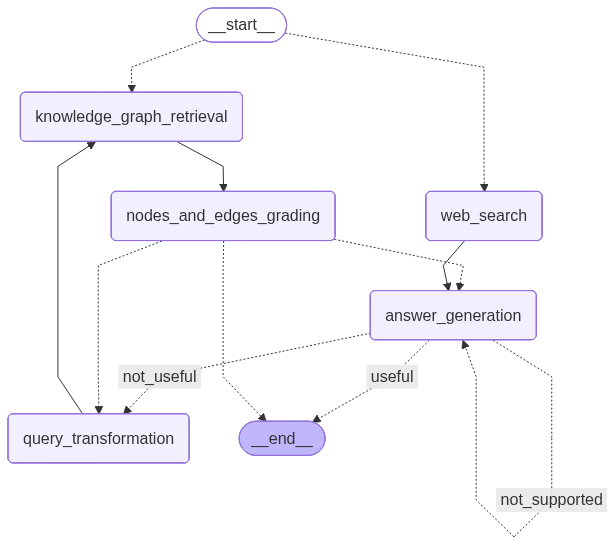

In [83]:
from IPython.display import Image, display

# Show the agent
display(Image(app.get_graph(xray=True).draw_mermaid_png()))